# Apply correction factor to Voyager data

Note differences from Fraternale analysis

- Much shorter intervals
- Different components (no transformations)

In [1]:
import numpy as np
import pandas as pd
import math as m
import pickle
from matplotlib import pyplot as plt
from matplotlib import gridspec
import matplotlib.dates as mdates

import sys
import os

sys.path.append(os.path.abspath(".."))
# So that I can read in the src files while working here in the notebooks/ folder

In [2]:
import src.utils as utils
import src.params as params
import src.sf_funcs as sf

# Set matplotlib font size
plt.rc("text", usetex=True)
plt.rc("font", family="serif", serif="Computer Modern", size=10)

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

In [3]:
def SmoothySpec(a, nums=None):
    """Smooth a curve using a moving average smoothing"""
    b = a.copy()
    if nums is None:
        nums = 2 * len(b) // 3
    for i in range(nums):
        b[i + 1 : -1] = 0.25 * b[i:-2] + 0.5 * b[i + 1 : -1] + 0.25 * b[i + 2 :]
    return b

In [4]:
from sunpy.timeseries import TimeSeries

spacecraft = "voyager"
cadence = "48s"
palette = params.gap_handling_palette

data = TimeSeries(
    "../data/raw/voyager/voyager1_48s_mag-vim_20110101_v01.cdf",
    # "../data/raw/voyager/voyager1_48s_mag-vim_20210101_v01.cdf",
    concatenate=True,  # Not strictly relevant here as only reading one file at a time
)

df_raw = data.to_dataframe()

df_raw = df_raw.loc[:, params.mag_vars_dict[spacecraft]]

In [5]:
df = df_raw.resample(cadence).mean()

In [6]:
del data, df_raw

<Axes: >

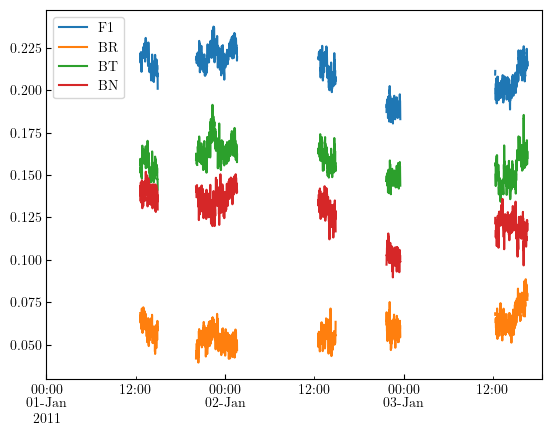

In [7]:
df[:5000].plot()

In [8]:
# Proportion of missing data
print(df.isna().sum() / len(df["F1"]))

F1    0.695021
BR    0.695021
BT    0.695021
BN    0.695021
dtype: float64


## Extract interval D1

In [9]:
# Get DOY 276-365 from the raw data
# subset = df["2021-02-01":"2021-05-01"]
subset = df["2011-10-03":"2011-12-31"]
del df

### Computing full SFs

In [10]:
subset_resampled = subset.resample("10min").mean()  # Now only 12,000 long

In [11]:
# Takes about 20-30 seconds,

sf_full = utils.calc_struct_sdk(
    data=subset_resampled["BT"],
    freq=1 / 600,
    orders=[1, 2, 3, 4],
    max_lag_fraction=0.5,
    plot=False,
)

In [12]:
subset_lint = subset_resampled.interpolate(method="linear")

sf_full_lint = utils.calc_struct_sdk(
    data=subset_lint["BT"],
    freq=1 / 600,
    orders=[1, 2, 3, 4],
    max_lag_fraction=0.5,
    plot=False,
)

### Computing correlation scale

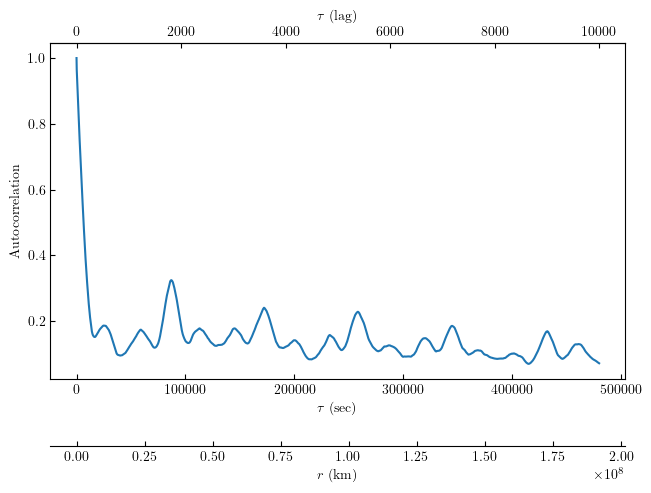

Correlation time = 8694.0s = 2.0 hours


In [13]:
time_lags_lr, r_vec_lr = utils.compute_nd_acf(
    [subset.BR, subset.BT, subset.BN],
    nlags=10000,  # Arbritrary large number
    plot=True,
)
tc_exp = utils.compute_outer_scale_exp_trick(time_lags_lr, r_vec_lr, plot=False)

print(f"Correlation time = {np.round(tc_exp)}s = {np.round(tc_exp/3600)} hours")
plt.show()

Calculating correlation time, using full 60-day dataset. Note highly wiggly ACF due to gaps. 

Also calculating $\lambda_C$ using integral method.
**DOESN'T WORK WITH NEW METHOD OF IDENTIFYING ZERO-CROSSING, BECAUSE THIS ACF DOES NOT CROSS ZERO**. See values derived from previous version of function below.

In [14]:
# fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
# tc, fig, ax = utils.compute_outer_scale_integral(time_lags_lr, r_vec_lr, fig, ax, False)
# # print(f"Correlation time = {np.round(tc)}s = {np.round(tc/3600)} hours")

# plt.show()
# print(tc / 60 / 60)
# print("hours")

# print(
#     "10 of these is ",
#     np.round(10 * tc / 60 / 60 / 24, 2),
#     "days, compared with full data length of",
#     subset.index[-1] - subset.index[0],
# )

Previous derived integral lengths (much longer than exponential fits)
- Interval 1 (118 au): 0.73 days
- Interval 2 (154 au): 0.57 days

## Computing standardised SFs

i.e. from intervals of 10,000 points across 10 correlation lengths, calculated up to lag 2,000.
Integral corr length `tc` has already been defined above.

In [15]:
# tc = 0.57 * 24 * 3600  # seconds, from previous calculation for int 1
tc = 0.73 * 24 * 3600  # seconds, from previous calculation for int 1

tc_n = 10
interval_length = params.int_length
new_cadence = tc_n * tc / interval_length

lags = np.arange(1, params.max_lag_prop * params.int_length)
powers = [2]
file_index = 0
int_index = 0
version = 0

In [16]:
int_std_full = subset.resample(str(np.round(new_cadence, 3)) + "S").mean()
int_std = int_std_full[:10000]

C:\Users\spann\AppData\Local\Temp\ipykernel_18448\675709484.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  int_std_full = subset.resample(str(np.round(new_cadence, 3)) + "S").mean()


In [17]:
len(int_std_full)

122212

In [18]:
del subset

In [19]:
int_norm = utils.normalize(int_std)
bad_input = int_norm[["BR", "BT", "BN"]]

In [20]:
print("Fraction missing:")

print(bad_input.isna().sum() / len(bad_input["BR"]))

missing = bad_input["BR"].isna().sum() / len(bad_input["BR"])

Fraction missing:
BR    0.6452
BT    0.6452
BN    0.6452
dtype: float64


In [21]:
bad_output = sf.compute_sf(bad_input, lags, powers, False, False)
bad_output["gap_handling"] = "naive"
bad_output["file_index"] = file_index
bad_output["int_index"] = int_index
bad_output["version"] = version

In [22]:
interp_input = (
    bad_input.interpolate(method="linear").ffill().bfill()
)  # Linearly interpolate (and, in case of missing values at edges, back and forward fill)
interp_output = sf.compute_sf(interp_input, lags, powers, False, False)

In [23]:
print("Standard deviation of standardised data:")
bad_input.std()

Standard deviation of standardised data:


BR    1.0
BT    1.0
BN    1.0
dtype: float32

In [24]:
interp_input_df = pd.DataFrame(interp_input)
interp_input_df.reset_index(inplace=True)  # Make time a column, not an index

interp_output["file_index"] = 0
interp_output["int_index"] = 0
interp_output["version"] = 0
interp_output["gap_handling"] = "lint"

# Correcting sample size and uncertainty for linear interpolation, same values as no handling
interp_output["n"] = bad_output["n"]
interp_output["missing_percent"] = bad_output["missing_percent"]
interp_output["sf_2_se"] = bad_output["sf_2_se"]

In [25]:
n_bins = 25
run_mode = "full"

sfs_gapped = pd.concat([interp_output, bad_output])

### Correcting SF

In [26]:
# Importing lookup table
n_bins = 25
with open(f"../results/{run_mode}/correction_lookup_3d_{n_bins}_bins_lint.pkl", "rb") as f:
    correction_lookup_3d = pickle.load(f)

## Smoothing correction

Previous method, employed in first paper submission, involved Gaussian blurring the heatmaps to create `correction_lookup_3d_blurred`, which replaced `correction_lookup_3d` in the following script. *See the GitHub, main branch, for this code.*

This time we are smoothing the actual correction values for each specific SF; this is done below and applied to the interval from the paper.


In [27]:
sfs_gapped["lag_tc"] = sfs_gapped["lag"] * 10 / len(int_std)
correction_lookup_3d["xedges"] = correction_lookup_3d["xedges"] * 10 / params.int_length

In [28]:
# Apply 2D and 3D scaling to test set, report avg errors

sfs_lint_corrected_3d = sf.compute_scaling(sfs_gapped, 3, correction_lookup_3d, n_bins)

Loaded 3D lookup table with 25 bins


In [29]:
from scipy.interpolate import interp1d


# Smoothing function
def smooth_scaling(x, y, num_bins=20):
    bin_edges = np.logspace(np.log10(x.min()), np.log10(x.max()), num_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    y_binned = np.array(
        [
            y[(x >= bin_edges[i]) & (x < bin_edges[i + 1])].mean()
            for i in range(len(bin_edges) - 1)
        ]
    )

    # Preserve the first and last values to prevent edge distortions
    # during extrapolation
    full_bins = np.insert(bin_centers, 0, bin_edges[0])
    full_bins = np.append(full_bins, bin_edges[-1])
    full_y_binned = np.insert(y_binned, 0, y.iloc[0])
    full_y_binned = np.append(full_y_binned, y.iloc[-1])

    interp_func = interp1d(
        full_bins, full_y_binned, kind="cubic", fill_value="extrapolate"
    )
    return interp_func(x)

In [30]:
single_sf = sfs_lint_corrected_3d[
    (sfs_lint_corrected_3d["int_index"] == int_index)
    & (sfs_lint_corrected_3d["version"] == version)
]

scaling_smooth = smooth_scaling(single_sf.lag, single_sf.scaling)
scaling_lower_smooth = smooth_scaling(single_sf.lag, single_sf.scaling_lower)
scaling_upper_smooth = smooth_scaling(single_sf.lag, single_sf.scaling_upper)

# Save to the main dataframe
sfs_lint_corrected_3d.loc[
    (sfs_lint_corrected_3d["int_index"] == int_index)
    & (sfs_lint_corrected_3d["version"] == version),
    "scaling_smooth",
] = scaling_smooth

sfs_lint_corrected_3d.loc[
    (sfs_lint_corrected_3d["int_index"] == int_index)
    & (sfs_lint_corrected_3d["version"] == version),
    "scaling_lower_smooth",
] = scaling_lower_smooth

sfs_lint_corrected_3d.loc[
    (sfs_lint_corrected_3d["int_index"] == int_index)
    & (sfs_lint_corrected_3d["version"] == version),
    "scaling_upper_smooth",
] = scaling_upper_smooth

# Apply scalings
sfs_lint_corrected_3d["sf_2_corrected_3d"] = (
    sfs_lint_corrected_3d["sf_2"] * sfs_lint_corrected_3d["scaling_smooth"]
)
sfs_lint_corrected_3d["sf_2_lower_corrected_3d"] = (
    sfs_lint_corrected_3d["sf_2"] * sfs_lint_corrected_3d["scaling_lower_smooth"]
)
sfs_lint_corrected_3d["sf_2_upper_corrected_3d"] = (
    sfs_lint_corrected_3d["sf_2"] * sfs_lint_corrected_3d["scaling_upper_smooth"]
)

In [31]:
correction_wide = sfs_lint_corrected_3d[
    [
        "file_index",
        "int_index",
        "version",
        "lag",
        "missing_percent",
        "sf_2_corrected_3d",
    ]
]
correction_long = pd.wide_to_long(
    correction_wide,
    ["sf_2"],
    i=["file_index", "int_index", "version", "lag", "missing_percent"],
    j="gap_handling",
    sep="_",
    suffix=r"\w+",
)
correction_bounds_wide = sfs_lint_corrected_3d[
    [
        "file_index",
        "int_index",
        "version",
        "lag",
        "missing_percent",
        "sf_2_lower_corrected_3d",
        "sf_2_upper_corrected_3d",
    ]
]

correction_bounds_long = pd.wide_to_long(
    correction_bounds_wide,
    ["sf_2_lower", "sf_2_upper"],
    i=["file_index", "int_index", "version", "lag", "missing_percent"],
    j="gap_handling",
    sep="_",
    suffix=r"\w+",
)

corrections_long = pd.merge(
    correction_long,
    correction_bounds_long,
    how="inner",
    on=[
        "file_index",
        "int_index",
        "version",
        "lag",
        "missing_percent",
        "gap_handling",
    ],
).reset_index()

# Adding the corrections, now as a form of "gap_handling", back to the gapped SF dataframe
sfs_gapped_corrected = pd.concat([sfs_gapped, corrections_long])

In [32]:
sf_corrected_raw = sfs_gapped_corrected.loc[
    (sfs_gapped_corrected["file_index"] == file_index)
    & (sfs_gapped_corrected["int_index"] == int_index)
    & (sfs_gapped_corrected["version"] == version)
    & (sfs_gapped_corrected["gap_handling"] == "corrected_3d"),
    ["lag", "sf_2"],
]

## Plot of correction + equiv. spectrum

In [33]:
# Fit a power law to the corrected SF
from scipy.optimize import curve_fit


def power_law(x, a, b):
    return a * x**b


sf_lags = sf_corrected_raw.lag.values
sf_corrected = sf_corrected_raw.sf_2.values
sf_corrected_es = sf_corrected * sf_lags / 6

popt, pcov = curve_fit(power_law, 1 / sf_lags[100:700], sf_corrected_es[100:700])

print(popt[1])

-1.6963047259045252


Let's compare with the values for the uncorrected version (JUST LOOK AT SECOND VALUE OF FIRST ARRAY)

In [34]:
# sf_corrected_raw = sfs_gapped_corrected.loc[
#     (sfs_gapped_corrected["file_index"] == file_index)
#     & (sfs_gapped_corrected["int_index"] == int_index)
#     & (sfs_gapped_corrected["version"] == version)
#     & (sfs_gapped_corrected["gap_handling"] == "lint"),
#     ["lag", "sf_2"],
# ]

# sf_corrected = sf_corrected_raw.sf_2.values
# sf_corrected_es = sf_corrected * sf_lags / 6

# curve_fit(power_law, 1 / sf_lags[100:700], sf_corrected_es[100:700])

In [35]:
# Delete rows where lag < 5

sfs_gapped_corrected = sfs_gapped_corrected[sfs_gapped_corrected["lag"] > 4]

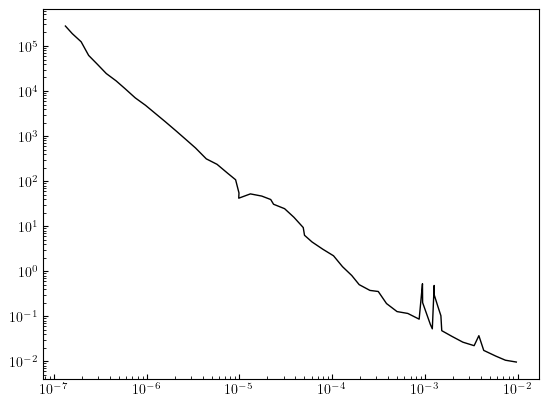

In [36]:
# Getting Fraternale results (Fig 2d)
# Read in the Fraternale et al. 2019 data

frat = pd.read_csv("../doc/paper/frat_2019_fig_2d.csv", header=None)
frat.columns = ["f", "psd"]
plt.loglog(frat["f"], frat["psd"], label="Fraternale et al. 2019", color="black", lw=1)

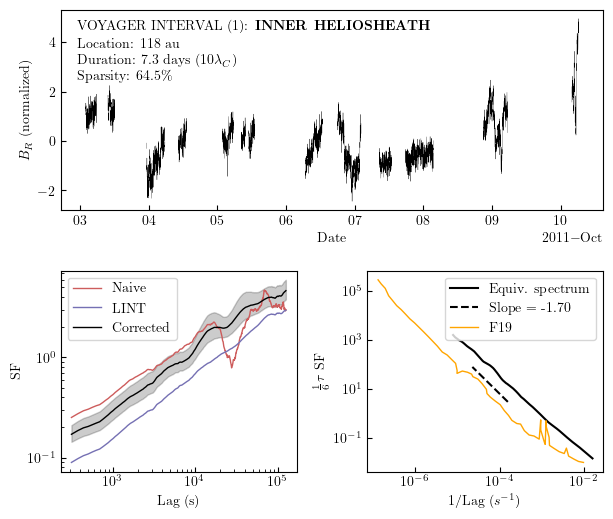

In [37]:
# fig, ax = plt.subplots(1, 3, figsize=(8, 2), constrained_layout=True)
fig = plt.figure(figsize=(7, 6))

gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])
gs.update(hspace=0.3, wspace=0.3)  # Change 0.5 to control the spacing
# First row, spanning both columns
ax1 = fig.add_subplot(gs[0, :])

# Second row, first column
ax2 = fig.add_subplot(gs[1, 0])

# Second row, second column
ax3 = fig.add_subplot(gs[1, 1])


file_index = 0
int_index = 0
version = 0

ax1.plot(bad_input.index, bad_input["BR"], color="black", lw=0.2, label="Raw")
# ax1.plot(
#     interp_input_df["Time"],
#     interp_input_df["BR"],
#     color="black",
#     lw=1,
#     label="Linearly interpolated",
# )
ax1.set_xlabel("Date")
ax1.set_ylabel(r"$B_R$ (normalized)")
ax1.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator())
)
# ax1.set_title("Magnetic field @ 154 AU (Voyager 1, interstellar medium)"),
# ax1.set_title("Magnetic field @ 118 AU (Voyager 1, inner heliosheath)")

ax1.annotate(
    # 118/154 au
    f"Location: 118 au\n \
    Duration: {np.round(tc*10/(24*60*60),1)} days ($10\\lambda_C$)\n \
    Sparsity: {float(missing*100):.1f}\%",
    xy=(1, 1),
    xycoords="axes fraction",
    xytext=(0.03, 0.65),
    # xytext=(0.03, 0.1),
    textcoords="axes fraction",
    transform=ax1.transAxes,
    c="black",
    # bbox=dict(facecolor="lightgrey", edgecolor="white", boxstyle="round", alpha=0.7),
)

ax1.annotate(
    r"VOYAGER INTERVAL (1): \textbf{INNER HELIOSHEATH}",
    # r"VOYAGER INTERVAL (2): \textbf{INTERSTELLAR MEDIUM}",
    xy=(1, 1),
    xycoords="axes fraction",
    xytext=(0.03, 0.9),
    # xytext=(0.28, 0.9),
    textcoords="axes fraction",
    transform=ax1.transAxes,
    c="black",
    # bbox=dict(facecolor="lightgrey", edgecolor="white", boxstyle="round", alpha=0.7),
)

ax2.set_xlabel("Lag (s)")
ax2.set_ylabel("SF")

ax2.plot(
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "naive"),
        "lag",
    ]
    * new_cadence,
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "naive"),
        "sf_2",
    ],
    color=palette["naive"],
    lw=1,
    label="Naive",
)
ax2.plot(
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "lint"),
        "lag",
    ]
    * new_cadence,
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "lint"),
        "sf_2",
    ],
    color=palette["lint"],
    lw=1,
    label="LINT",
)
ax2.plot(
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "corrected_3d"),
        "lag",
    ]
    * new_cadence,
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "corrected_3d"),
        "sf_2",
    ],
    color=palette["corrected_3d"],
    lw=1,
    label="Corrected",
)
ax2.fill_between(
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "corrected_3d"),
        "lag",
    ]
    * new_cadence,
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "corrected_3d"),
        "sf_2_lower",
    ],
    sfs_gapped_corrected.loc[
        (sfs_gapped_corrected["file_index"] == file_index)
        & (sfs_gapped_corrected["int_index"] == int_index)
        & (sfs_gapped_corrected["version"] == version)
        & (sfs_gapped_corrected["gap_handling"] == "corrected_3d"),
        "sf_2_upper",
    ],
    color=palette["corrected_3d"],
    alpha=0.2,
)
ax2.legend(loc="upper left")  # lower right
ax2.semilogx()
ax2.semilogy()

# Third panel (bottom right)
ax3.plot(
    1 / (sf_lags * new_cadence),
    sf_corrected_es,
    label="Equiv. spectrum",
    c=palette["corrected_3d"],
)
ax3.plot(
    1 / (sf_lags[100:700] * new_cadence),
    power_law(1 / sf_lags[100:700], *popt) / 5,
    label="Slope = {:.2f}".format(popt[1]),
    ls="--",
    color="black",
)
ax3.plot(frat["f"], frat["psd"], label="F19", color="orange", lw=1)
ax3.semilogx()
ax3.semilogy()
ax3.legend(loc="upper right")
ax3.set_xlabel("1/Lag ($s^{-1}$)")
ax3.set_ylabel(r"$\frac{1}{6} \tau$ SF")
# plt.savefig("../results/full/plots/voyager/voyager_lism.pdf")
# plt.savefig("../results/full/plots/voyager/voyager_ihs.pdf")
plt.show()

Our spectrum does not go to as large scales (low frequencies) as F19, because we are using a much shorter interval. Also the amplitudes do not match (likely to do with our standardization, or otherwise a bias Mark might know about). However, **the slopes match up quite well**. Here is the original fig of theirs, with an overlapping date range (ours is the first week of their 3-month long interval):

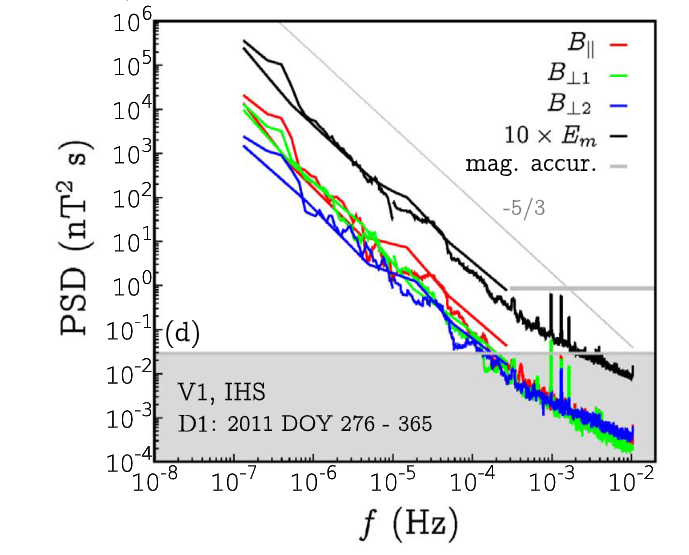

In [44]:
def contiguous_missing_proportion_histogram(
    data,
    bins: int = 10,
    xmax: int = None,
    title: str = "Proportion of Dataset Missing by Gap Length",
    figsize = (10, 6),
    time_unit: str = "seconds",
    resolution: int = 48,  # Time per data point in seconds (default: 48s)
) -> pd.Series:
    """
    Create a histogram showing the proportion of the dataset lost due to gaps of each length.

    Parameters:
    -----------
    data : pd.Series or list
        The time series data with potential missing values (NaN or None)
    bins : int
        Number of bins for the histogram
    max_gap_length : int, optional
        Maximum gap length to consider for the histogram
    title : str
        Title for the plot
    figsize : tuple
        Figure size (width, height) in inches
    time_unit : str
        Unit for time ('seconds', 'minutes', 'hours', 'days')
    resolution : int
        Number of seconds per data point (default: 48s)

    Returns:
    --------
    pd.Series : Proportion of dataset missing due to each gap length
    """
    # Convert to pandas Series if list is provided
    if isinstance(data, list):
        data = pd.Series(data)

    # Find missing values
    is_missing = data.isna()

    # If no missing values, return early
    if not is_missing.any():
        print("No missing values found in the data.")
        return pd.Series()

    # Detect contiguous missing value gaps
    padded = pd.concat(
        [pd.Series([False]), is_missing, pd.Series([False])]
    ).reset_index(drop=True)
    starts = padded[~padded.shift(1).astype(bool) & padded].index - 1
    ends = padded[padded & ~padded.shift(-1).astype(bool)].index - 1

    # Calculate lengths of contiguous missing intervals
    gap_lengths = ends - starts + 1

    # Compute missing fraction per gap length
    gap_series = pd.Series(gap_lengths)
    gap_proportions = gap_series.groupby(gap_series).sum() / len(data)

    # Time conversion factors
    time_conversion = {
        "seconds": 1,
        "minutes": 1 / 60,
        "hours": 1 / 3600,
        "days": 1 / 86400,
    }

    if time_unit not in time_conversion:
        raise ValueError(
            f"Invalid time_unit: {time_unit}. Choose from {list(time_conversion.keys())}."
        )

    # Convert resolution from seconds to the chosen time unit
    resolution_in_units = resolution * time_conversion[time_unit]

    # Prepare figure
    fig, ax = plt.subplots(figsize=figsize)

    if xmax:
        ax.set_xlim(0, xmax)

    # Plot bar chart
    ax.bar(gap_proportions.index, gap_proportions, edgecolor="black", alpha=0.7)

    # Add labels and title
    ax.set_xlabel("Number of Contiguous Missing Values")
    ax.set_ylabel("Proportion of Dataset Missing")
    ax.set_title(title)

    # Use log scale only if needed
    # if gap_proportions.max() / gap_proportions.min() > 100:
    #     ax.set_yscale("log")

    # Add grid for better readability
    ax.grid(axis="y", alpha=0.3)

    # Add secondary x-axis with gap length converted to time units
    def data_points_to_time(x):
        return (
            x * resolution_in_units
        )  # Convert missing data points to chosen time unit

    def time_to_data_points(x):
        return x / resolution_in_units  # Convert time back to missing data points

    ax2 = ax.secondary_xaxis(
        "top", functions=(data_points_to_time, time_to_data_points)
    )
    ax2.set_xlabel(f"Time ({time_unit})")

    plt.tight_layout()
    #plt.savefig(f"../results/cleaning/gap_analysis_pdf_voyager2.png", dpi=300)
    plt.show()

In [41]:
bad_input.BR.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 10000 entries, 2011-10-03 00:00:00 to 2011-10-10 07:10:56.928000
Freq: 63072ms
Series name: BR
Non-Null Count  Dtype  
--------------  -----  
3548 non-null   float32
dtypes: float32(1)
memory usage: 117.2 KB


In [42]:
49248/ 1000

49.248

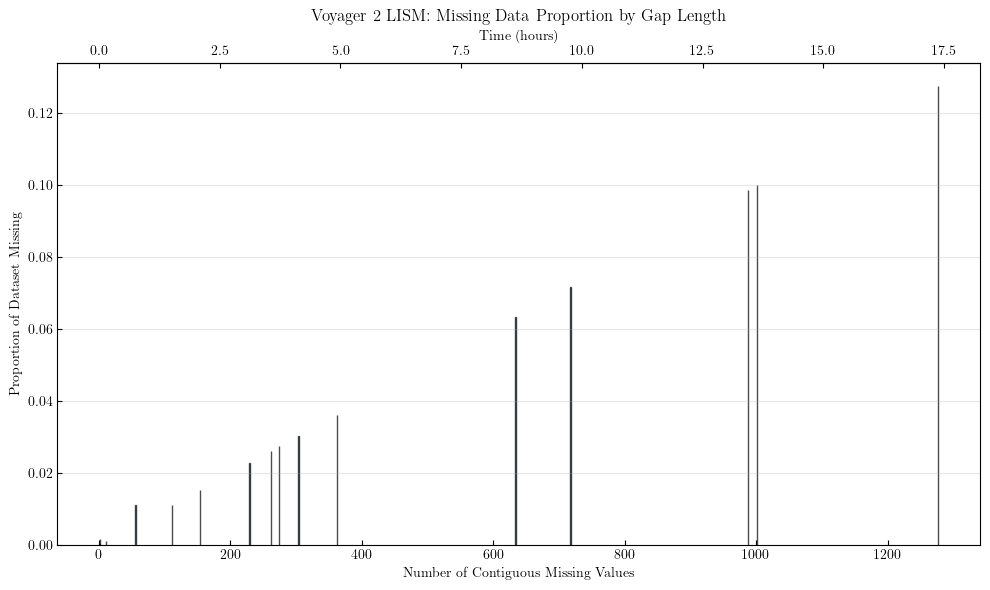

In [43]:
contiguous_missing_proportion_histogram(
    bad_input.BR,
    #xmax=4000,
    time_unit="hours",
    title="Voyager 2 LISM: Missing Data Proportion by Gap Length",
    resolution=49
)